In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
import nltk

In [2]:
df = pd.read_csv('mental_health.csv')
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df = df.drop('Unnamed: 0', axis=1)

In [4]:
df.head(10)

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
5,"every break, you must be nervous, like somethi...",Anxiety
6,"I feel scared, anxious, what can I do? And may...",Anxiety
7,Have you ever felt nervous but didn't know why?,Anxiety
8,"I haven't slept well for 2 days, it's like I'm...",Anxiety
9,"I'm really worried, I want to cry.",Anxiety


In [5]:
df.describe()

,statement,status
count,52681,53043
unique,51073,7
top,what do you mean?,Normal
freq,22,16351


In [6]:
df.isnull().sum()

statement    362
status         0
dtype: int64

In [7]:
df.dropna(inplace=True)


In [8]:
df.isnull().sum()

statement    0
status       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(1588)

In [10]:
df.shape

(52681, 2)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52681 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     52681 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [12]:
countd_df = df['status'].value_counts()

In [13]:
print(countd_df)

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_19600\3681613266.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count.index, y=count.values, palette='viridis')


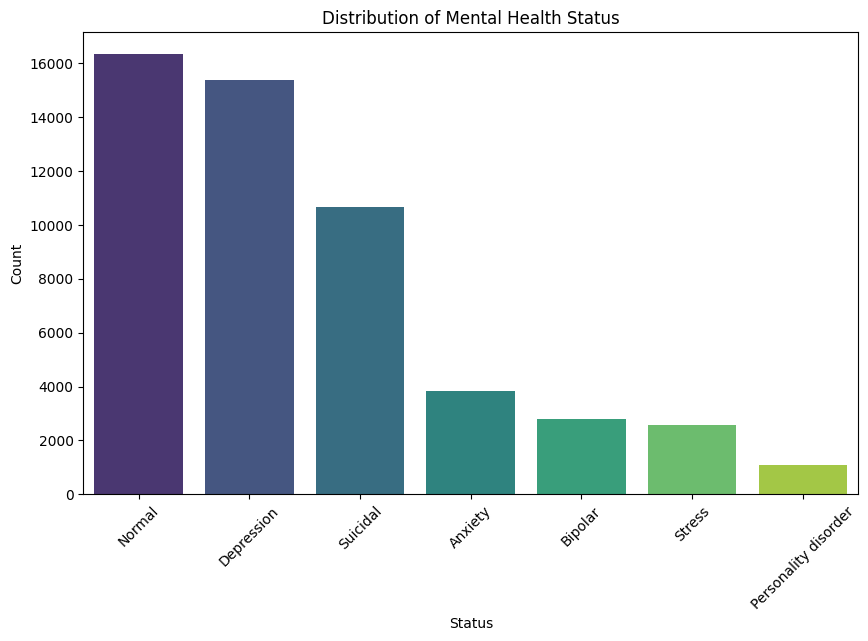

In [14]:
count = df['status'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=count.index, y=count.values, palette='viridis')
plt.title('Distribution of Mental Health Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

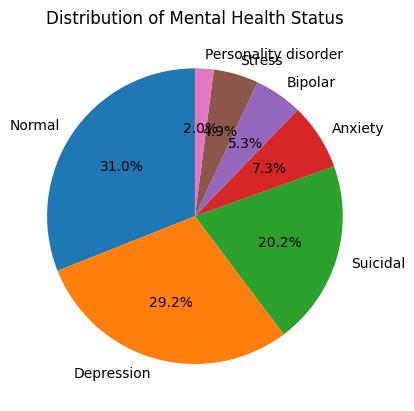

In [15]:
df['status'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Mental Health Status')
plt.ylabel('')
plt.show()


In [17]:
df['statement'] = df['statement'].astype(str)
df['statement'] = df['statement'].str.lower()
df['statement'] = df['statement'].str.replace(r'\d+', '', regex=True)
df['statement'] = df['statement'].str.replace(r'\W+', ' ', regex=True)


In [20]:
import re
from nltk.tokenize import word_tokenize
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [23]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [26]:


# Custom stopwords
custom_stopwords = {
    'drop', 'v', 'i', 'am', 'the', 'and', 'to', 'a', 'going', 'market', 'bag',
    'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'has', 'have', 'had', 'do', 'does', 'did', 'doing', '',
    'it', 'its', 'this', 'that', 'these', 'those',
    'he', 'she', 'they', 'them', 'his', 'her', 'their', 'my', 'your', 'our',
    'me', 'you', 'us', 'we', 'him', 'done', 'there'
}
stop_words = set(stopwords.words('english')).union(custom_stopwords)
lemmatizer = WordNetLemmatizer()

# Preprocessing function
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove digits
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = re.sub(rf"[{re.escape(string.punctuation)}]", '', text)
    # Tokenize (simple)
    tokens = text.split()
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)


df['statement'] = df['statement'].apply(preprocess_text)

# View result
print(df[['statement']])


                                               statement
0                                                oh gosh
1      trouble sleeping confused mind restless heart ...
2      wrong back dear forward doubt stay restless re...
3             shifted focus something else still worried
4                       restless restless month boy mean
...                                                  ...
53038  nobody take seriously dealt depression anxiety...
53039  selfishness feel good like belong world think ...
53040              way sleep better sleep night med help
53041  public speaking tip hi give presentation work ...
53042  really bad door anxiety scared lock door somet...

[52681 rows x 1 columns]


In [27]:
# Save the entire DataFrame to a CSV file
df.to_csv('cleaned_statements.csv', index=False)
